In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


In [2]:
traffic = pd.read_csv(
    "All Recorded Traffic.txt",   # <- change to your exact filename
    sep="\t",
    na_values=["", " ", "NULL", "null", "NaN"]
)

bus = pd.read_csv(
    "All Recorded PABT Bus.txt",
    sep="\t",
    na_values=["", " ", "NULL", "null", "NaN"]
)

passenger = pd.read_csv(
    "All Recorded PABT Passenger.txt",
    sep="\t",
    na_values=["", " ", "NULL", "null", "NaN"]
)

speeds = pd.read_csv(
    "Facility Mobility Speeds.txt",
    sep="\t",
    na_values=["", " ", "NULL", "null", "NaN"]
)

print("Traffic:", traffic.shape)
print("Bus:", bus.shape)
print("Passenger:", passenger.shape)
print("Speeds:", speeds.shape)
traffic.head()


Traffic: (5383378, 30)
Bus: (2784, 4)
Passenger: (2786, 4)
Speeds: (192, 7)


,DAY,DATE,FAC,LANE,TIME,TOTAL,CLASS 1,CLASS 2,CLASS 3,CLASS 4,CLASS 5,CLASS 6,CLASS 7,CLASS 8,CLASS 9,CLASS 11,CASH,EZPASS,VIOLATION,LANEMODE,Month,FAC_B,Autos,Small_T,Large_T,Buses,Yr,FAC_G,FAC_G2,Day_Name
0,4,2022-09-15 00:00:00.000,2,6,100,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,D,9,Lincoln,1,0,0,0,2022,Tunnels,Lincoln,Thursday
1,4,2022-09-15 00:00:00.000,2,6,300,1,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0,1,0,D,9,Lincoln,1,0,0,0,2022,Tunnels,Lincoln,Thursday
2,4,2022-09-15 00:00:00.000,2,6,400,73,67.0,2.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,NaN,0,66,7,D,9,Lincoln,67,3,1,2,2022,Tunnels,Lincoln,Thursday
3,4,2022-09-15 00:00:00.000,2,6,500,713,673.0,10.0,4.0,NaN,1.0,NaN,NaN,6.0,13.0,6.0,0,644,69,D,9,Lincoln,679,14,1,19,2022,Tunnels,Lincoln,Thursday
4,4,2022-09-15 00:00:00.000,2,6,600,1003,974.0,14.0,1.0,1.0,NaN,NaN,NaN,3.0,NaN,10.0,0,909,94,D,9,Lincoln,984,15,1,3,2022,Tunnels,Lincoln,Thursday


In [3]:
def dataset_inventory(df, name):
    return {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Cells": int(df.isna().sum().sum()),
        "Column Names (first 20)": ", ".join(df.columns[:20]) + (" ..." if len(df.columns) > 20 else "")
    }

inventory = pd.DataFrame([
    dataset_inventory(traffic, "All Recorded Traffic"),
    dataset_inventory(bus, "PABT_Bus"),
    dataset_inventory(passenger, "PABT_Passenger"),
    dataset_inventory(speeds, "Facility_Mobility_Speeds")
])

inventory


,Dataset,Rows,Columns,Missing Cells,Column Names (first 20)
0,All Recorded Traffic,5383378,30,8511288,"DAY, DATE, FAC, LANE, TIME, TOTAL, CLASS 1, CL..."
1,PABT_Bus,2784,4,0,"Start_Date, End_Date, Carrier, Volume"
2,PABT_Passenger,2786,4,8,"Start_Date, End_Date, Carrier, Volume"
3,Facility_Mobility_Speeds,192,7,0,"Facility, Freeflow, Month_Year, Avg_Speed, Dir..."


In [4]:
traffic.info()
bus.info()
passenger.info()
speeds.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5383378 entries, 0 to 5383377
Data columns (total 30 columns):
 #   Column     Dtype  
---  ------     -----  
 0   DAY        int64  
 1   DATE       object 
 2   FAC        int64  
 3   LANE       int64  
 4   TIME       int64  
 5   TOTAL      int64  
 6   CLASS 1    float64
 7   CLASS 2    float64
 8   CLASS 3    float64
 9   CLASS 4    float64
 10  CLASS 5    float64
 11  CLASS 6    float64
 12  CLASS 7    float64
 13  CLASS 8    float64
 14  CLASS 9    float64
 15  CLASS 11   float64
 16  CASH       int64  
 17  EZPASS     int64  
 18  VIOLATION  int64  
 19  LANEMODE   object 
 20  Month      int64  
 21  FAC_B      object 
 22  Autos      int64  
 23  Small_T    int64  
 24  Large_T    int64  
 25  Buses      int64  
 26  Yr         int64  
 27  FAC_G      object 
 28  FAC_G2     object 
 29  Day_Name   object 
dtypes: float64(10), int64(14), object(6)
memory usage: 1.2+ GB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2784 

In [5]:
def missing_report(df):
    miss = df.isna().sum().sort_values(ascending=False)
    return pd.DataFrame({
        "Missing_Count": miss,
        "Missing_%": (miss / len(df) * 100).round(2)
    })

display(missing_report(traffic).head(15))
display(missing_report(bus).head(15))
display(missing_report(passenger).head(15))
display(missing_report(speeds).head(15))


,Missing_Count,Missing_%
CLASS 6,1354198,25.16
CLASS 7,1162245,21.59
CLASS 11,1011351,18.79
CLASS 4,977073,18.15
CLASS 9,970739,18.03
CLASS 8,965627,17.94
CLASS 5,851663,15.82
CLASS 3,798675,14.84
CLASS 2,407007,7.56
CLASS 1,12710,0.24


,Missing_Count,Missing_%
Start_Date,0,0.0
End_Date,0,0.0
Carrier,0,0.0
Volume,0,0.0


,Missing_Count,Missing_%
Start_Date,2,0.07
End_Date,2,0.07
Carrier,2,0.07
Volume,2,0.07


,Missing_Count,Missing_%
Facility,0,0.0
Freeflow,0,0.0
Month_Year,0,0.0
Avg_Speed,0,0.0
Direction,0,0.0
Delta,0,0.0
Facility_Order,0,0.0


In [6]:
traffic_clean = traffic.dropna(how="all").copy()
bus_clean = bus.dropna(how="all").copy()
passenger_clean = passenger.dropna(how="all").copy()
speeds_clean = speeds.dropna(how="all").copy()

print("Traffic blank rows removed:", traffic.shape, "->", traffic_clean.shape)
print("Passenger blank rows removed:", passenger.shape, "->", passenger_clean.shape)

print("Traffic duplicates:", traffic_clean.duplicated().sum())
print("Bus duplicates:", bus_clean.duplicated().sum())
print("Passenger duplicates:", passenger_clean.duplicated().sum())
print("Speeds duplicates:", speeds_clean.duplicated().sum())

# If you want to drop duplicates (recommended if duplicates > 0)
# traffic_clean = traffic_clean.drop_duplicates()
# bus_clean = bus_clean.drop_duplicates()
# passenger_clean = passenger_clean.drop_duplicates()
# speeds_clean = speeds_clean.drop_duplicates()


Traffic blank rows removed: (5383378, 30) -> (5383378, 30)
Passenger blank rows removed: (2786, 4) -> (2784, 4)
Traffic duplicates: 0
Bus duplicates: 0
Passenger duplicates: 0
Speeds duplicates: 0


In [7]:
# Parse DATE
traffic_clean["DATE"] = pd.to_datetime(traffic_clean["DATE"], errors="coerce")

# TIME like 100, 2300 -> "0100", "2300"
traffic_clean["TIME_STR"] = traffic_clean["TIME"].astype(str).str.zfill(4)
traffic_clean["HOUR"] = traffic_clean["TIME_STR"].str[:2].astype(int)
traffic_clean["MINUTE"] = traffic_clean["TIME_STR"].str[2:].astype(int)

# Create helpful calendar columns
traffic_clean["YEAR"] = traffic_clean["DATE"].dt.year
traffic_clean["MONTH"] = traffic_clean["DATE"].dt.month
traffic_clean["DAY_NAME"] = traffic_clean["DATE"].dt.day_name()

# Class columns: treat NULL as 0
class_cols = ["CLASS 1","CLASS 2","CLASS 3","CLASS 4","CLASS 5",
              "CLASS 6","CLASS 7","CLASS 8","CLASS 9","CLASS 11"]

for c in class_cols:
    if c in traffic_clean.columns:
        traffic_clean[c] = traffic_clean[c].fillna(0)


In [8]:
existing_class_cols = [c for c in class_cols if c in traffic_clean.columns]
traffic_clean["CLASS_SUM"] = traffic_clean[existing_class_cols].sum(axis=1)

traffic_clean["TOTAL_MATCH"] = traffic_clean["TOTAL"] == traffic_clean["CLASS_SUM"]

traffic_clean["TOTAL_MATCH"].value_counts()


TOTAL_MATCH
True    5383378
Name: count, dtype: int64

In [9]:
def normalize_text(series):
    return (series.astype(str)
                  .str.strip()
                  .str.replace(r"\s+", " ", regex=True)
                  .str.upper())

# Traffic
for col in ["FAC_B", "FAC_G", "FAC_G2", "LANEMODE", "Day_Name"]:
    if col in traffic_clean.columns:
        traffic_clean[col] = normalize_text(traffic_clean[col])

# PABT + Speeds
for df in [bus_clean, passenger_clean, speeds_clean]:
    for col in ["Carrier", "Facility", "Direction"]:
        if col in df.columns:
            df[col] = normalize_text(df[col])


In [10]:
def descriptive_stats(df):
    num = df.select_dtypes(include=[np.number])
    if num.empty:
        return pd.DataFrame()

    mode_vals = num.mode(dropna=True)
    mode_first = mode_vals.iloc[0] if not mode_vals.empty else pd.Series(index=num.columns, dtype=float)

    stats = pd.DataFrame({
        "Mean": num.mean(),
        "Median": num.median(),
        "Mode": mode_first,
        "Variance": num.var(),
        "Std_Dev": num.std(),
        "Min": num.min(),
        "Max": num.max()
    })
    stats["Range"] = stats["Max"] - stats["Min"]
    return stats

traffic_stats = descriptive_stats(traffic_clean)
bus_stats = descriptive_stats(bus_clean)
passenger_stats = descriptive_stats(passenger_clean)
speeds_stats = descriptive_stats(speeds_clean)

traffic_stats.head(15)


,Mean,Median,Mode,Variance,Std_Dev,Min,Max,Range
DAY,3.986831,4.0,1.0,4.004726,2.001181,1.0,7.0,6.0
FAC,5.138543,6.0,7.0,7.609608,2.758552,1.0,9.0,8.0
LANE,17.794426,10.0,4.0,386.980597,19.671822,1.0,74.0,73.0
TIME,1168.660793,1200.0,900.0,460662.401531,678.721152,0.0,2300.0,2300.0
TOTAL,270.174275,199.0,1.0,67914.804101,260.604689,0.0,3938.0,3938.0
CLASS 1,245.789914,175.0,1.0,61680.239678,248.355068,0.0,3148.0,3148.0
CLASS 2,6.818461,2.0,0.0,209.081101,14.459637,0.0,256.0,256.0
CLASS 3,2.178960,0.0,0.0,26.917804,5.188237,0.0,237.0,237.0
CLASS 4,1.492549,0.0,0.0,15.533956,3.941314,0.0,93.0,93.0
CLASS 5,6.884244,0.0,0.0,411.141697,20.276629,0.0,471.0,471.0


In [11]:
# Busiest hours (total volume)
traffic_clean.groupby("HOUR")["TOTAL"].sum().sort_values(ascending=False).head(10)
# Violation rate (avoid divide-by-zero)
traffic_clean["VIOLATION_RATE"] = np.where(
    traffic_clean["TOTAL"] > 0,
    traffic_clean["VIOLATION"] / traffic_clean["TOTAL"],
    np.nan
)

traffic_clean["VIOLATION_RATE"].describe()


count    5.383242e+06
mean     6.961706e-02
std      1.274771e-01
min      0.000000e+00
25%      1.923077e-02
50%      3.723404e-02
75%      6.910569e-02
max      4.000000e+00
Name: VIOLATION_RATE, dtype: float64

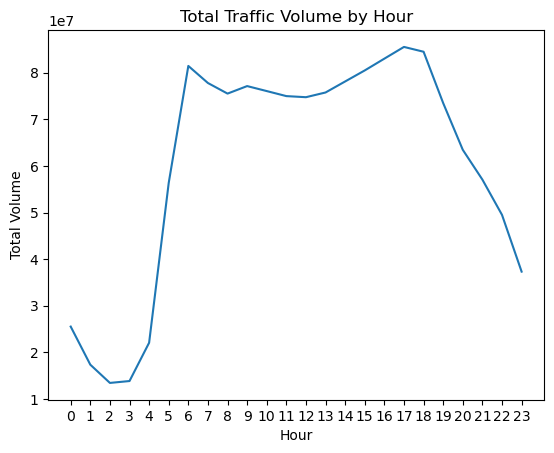

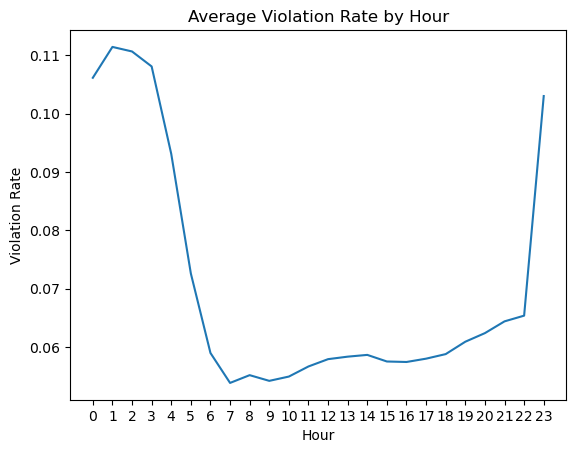

In [13]:
hourly = traffic_clean.groupby("HOUR", as_index=False)["TOTAL"].sum()

plt.figure()
plt.plot(hourly["HOUR"], hourly["TOTAL"])
plt.title("Total Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Total Volume")
plt.xticks(range(0,24))
plt.show()

viol_hour = traffic_clean.groupby("HOUR", as_index=False)["VIOLATION_RATE"].mean()

plt.figure()
plt.plot(viol_hour["HOUR"], viol_hour["VIOLATION_RATE"])
plt.title("Average Violation Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Violation Rate")
plt.xticks(range(0,24))
plt.show()



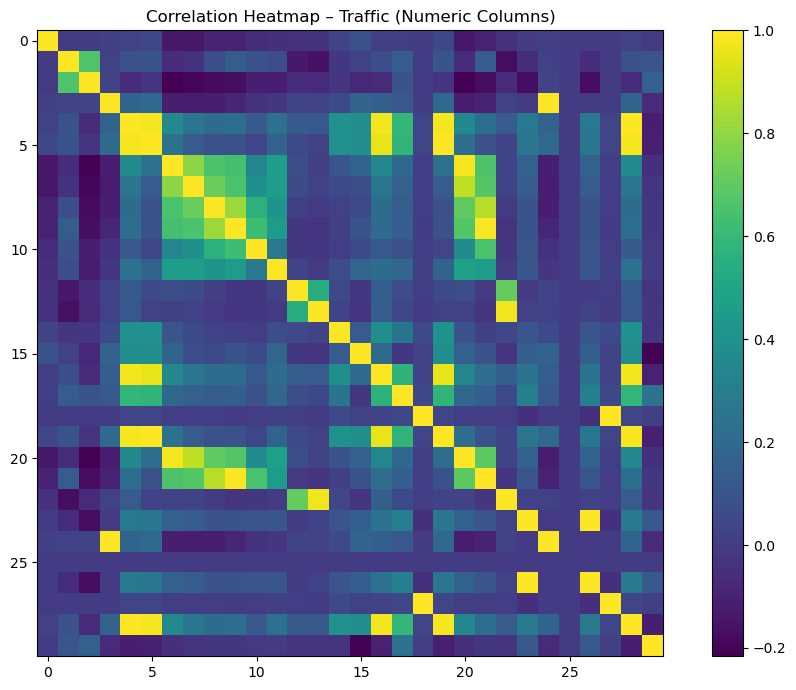

In [14]:
traffic_corr = traffic_clean.select_dtypes(include=[np.number]).corr(numeric_only=True)
traffic_corr.loc[["TOTAL","VIOLATION","CASH","EZPASS"], :].head(15)

plt.figure(figsize=(10,7))
plt.imshow(traffic_corr.fillna(0).values)
plt.title("Correlation Heatmap – Traffic (Numeric Columns)")
plt.colorbar()
plt.tight_layout()
plt.show()


In [15]:
x = traffic_clean["TOTAL"].dropna()
q1, q3 = x.quantile(0.25), x.quantile(0.75)
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr

out_total = traffic_clean[(traffic_clean["TOTAL"] < low) | (traffic_clean["TOTAL"] > high)]
print("TOTAL outliers:", out_total.shape[0], "bounds:", (low, high))
out_total.head()


TOTAL outliers: 339366 bounds: (np.float64(-315.5), np.float64(760.5))


,DAY,DATE,FAC,LANE,TIME,TOTAL,CLASS 1,CLASS 2,CLASS 3,CLASS 4,CLASS 5,CLASS 6,CLASS 7,CLASS 8,CLASS 9,CLASS 11,CASH,EZPASS,VIOLATION,LANEMODE,Month,FAC_B,Autos,Small_T,Large_T,Buses,Yr,FAC_G,FAC_G2,Day_Name,TIME_STR,HOUR,MINUTE,YEAR,MONTH,DAY_NAME,CLASS_SUM,TOTAL_MATCH,VIOLATION_RATE
4,4,2022-09-15,2,6,600,1003,974.0,14.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0,10.0,0,909,94,D,9,LINCOLN,984,15,1,3,2022,TUNNELS,LINCOLN,THURSDAY,0600,6,0,2022,9,Thursday,1003.0,True,0.093719
169,2,2024-08-13,1,8,500,807,704.0,88.0,9.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,99,670,38,D,8,HOLLAND,709,97,0,1,2024,TUNNELS,HOLLAND,TUESDAY,0500,5,0,2024,8,Tuesday,807.0,True,0.047088
171,7,2024-08-18,5,2,1000,932,928.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,112,784,36,D,8,GOETHALS,931,1,0,0,2024,SIB,GOETHALS,SUNDAY,1000,10,0,2024,8,Sunday,932.0,True,0.038627
172,7,2024-08-18,5,2,1100,1034,1030.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,141,867,26,D,8,GOETHALS,1030,3,0,1,2024,SIB,GOETHALS,SUNDAY,1100,11,0,2024,8,Sunday,1034.0,True,0.025145
173,7,2024-08-18,5,2,1200,826,824.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,99,701,26,D,8,GOETHALS,825,1,0,0,2024,SIB,GOETHALS,SUNDAY,1200,12,0,2024,8,Sunday,826.0,True,0.031477


In [16]:
# Traffic month key
traffic_monthly = (traffic_clean
                   .groupby(["YEAR","MONTH"], as_index=False)
                   .agg(
                       TOTAL_TRAFFIC=("TOTAL","sum"),
                       TOTAL_VIOLATIONS=("VIOLATION","sum"),
                       TOTAL_CASH=("CASH","sum"),
                       TOTAL_EZPASS=("EZPASS","sum")
                   ))

traffic_monthly["Month"] = (traffic_monthly["YEAR"].astype(str) + "-" +
                            traffic_monthly["MONTH"].astype(str).str.zfill(2))

traffic_monthly.head()


,YEAR,MONTH,TOTAL_TRAFFIC,TOTAL_VIOLATIONS,TOTAL_CASH,TOTAL_EZPASS,Month
0,2013,1,9062629,223576,1497062,7342015,2013-01
1,2013,2,8107473,198714,1343722,6565059,2013-02
2,2013,3,9633352,227608,1686217,7719561,2013-03
3,2013,4,9638288,233399,1630975,7773937,2013-04
4,2013,5,10138080,259641,1751667,8126800,2013-05


In [17]:
# Speeds Month_Year -> Month (YYYY-MM)
if "Month_Year" in speeds_clean.columns:
    speeds_clean["Month"] = pd.to_datetime(speeds_clean["Month_Year"], errors="coerce").dt.to_period("M").astype(str)

speeds_clean[["Month_Year","Month"]].head()


,Month_Year,Month
0,2025-03-01 00:00:00.000,2025-03
1,2025-03-01 00:00:00.000,2025-03
2,2025-03-01 00:00:00.000,2025-03
3,2025-03-01 00:00:00.000,2025-03
4,2025-03-01 00:00:00.000,2025-03


In [18]:
for df in [bus_clean, passenger_clean]:
    if "Start_Date" in df.columns:
        df["Start_Date"] = pd.to_datetime(df["Start_Date"], errors="coerce")
        df["Month"] = df["Start_Date"].dt.to_period("M").astype(str)

bus_monthly = (bus_clean.groupby("Month", as_index=False)["Volume"].sum()
               .rename(columns={"Volume":"PABT_Bus_Volume"})) if "Volume" in bus_clean.columns else pd.DataFrame()

pass_monthly = (passenger_clean.groupby("Month", as_index=False)["Volume"].sum()
                .rename(columns={"Volume":"PABT_Passenger_Volume"})) if "Volume" in passenger_clean.columns else pd.DataFrame()

bus_monthly.head(), pass_monthly.head()


(     Month  PABT_Bus_Volume
 0  2020-12           9398.0
 1  2021-01           9459.0
 2  2021-02           9604.0
 3  2021-03          11960.0
 4  2021-04          10143.0,
      Month  PABT_Passenger_Volume
 0  2020-12               121859.0
 1  2021-01               125018.0
 2  2021-02               128727.0
 3  2021-03               173806.0
 4  2021-04               151467.0)

In [19]:
final_dataset = (traffic_monthly
                 .merge(speeds_clean, on="Month", how="left")
                 .merge(bus_monthly, on="Month", how="left")
                 .merge(pass_monthly, on="Month", how="left"))

final_dataset.head()


,YEAR,MONTH,TOTAL_TRAFFIC,TOTAL_VIOLATIONS,TOTAL_CASH,TOTAL_EZPASS,Month,Facility,Freeflow,Month_Year,Avg_Speed,Direction,Delta,Facility_Order,PABT_Bus_Volume,PABT_Passenger_Volume
0,2013,1,9062629,223576,1497062,7342015,2013-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013,2,8107473,198714,1343722,6565059,2013-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013,3,9633352,227608,1686217,7719561,2013-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013,4,9638288,233399,1630975,7773937,2013-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2013,5,10138080,259641,1751667,8126800,2013-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
sample_traffic = (
    traffic_clean
    .groupby(sample_cols, group_keys=False)
    .apply(
        lambda x: x.sample(min(len(x), 3), random_state=42),
        include_groups=False
    )
    .reset_index(drop=True)
)
sample_traffic.head(20)


,DAY,DATE,FAC,LANE,TIME,TOTAL,CLASS 1,CLASS 2,CLASS 3,CLASS 4,CLASS 5,CLASS 6,CLASS 7,CLASS 8,CLASS 9,CLASS 11,CASH,EZPASS,VIOLATION,LANEMODE,Month,Autos,Small_T,Large_T,Buses,Yr,FAC_G,FAC_G2,Day_Name,TIME_STR,MINUTE,YEAR,MONTH,DAY_NAME,CLASS_SUM,TOTAL_MATCH,VIOLATION_RATE
0,6,2023-10-14,4,6,0,37,36.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,30,1,D,10,36,1,0,0,2023,SIB,BAYONNE,SATURDAY,0000,0,2023,10,Saturday,37.0,True,0.027027
1,2,2013-02-12,4,4,0,50,45.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0,49,1,D,2,45,0,5,0,2013,SIB,BAYONNE,TUESDAY,0000,0,2013,2,Tuesday,50.0,True,0.020000
2,6,2013-05-11,4,4,0,122,114.0,1.0,2.0,1.0,3.0,0.0,0.0,0.0,0.0,1.0,0,116,6,D,5,115,3,4,0,2013,SIB,BAYONNE,SATURDAY,0000,0,2013,5,Saturday,122.0,True,0.049180
3,3,2021-06-23,4,6,100,6,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,6,0,D,6,6,0,0,0,2021,SIB,BAYONNE,WEDNESDAY,0100,0,2021,6,Wednesday,6.0,True,0.000000
4,4,2023-11-30,4,4,100,52,37.0,2.0,7.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,13,38,1,D,11,37,9,6,0,2023,SIB,BAYONNE,THURSDAY,0100,0,2023,11,Thursday,52.0,True,0.019231
5,7,2013-01-27,4,8,100,22,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14,7,1,M,1,22,0,0,0,2013,SIB,BAYONNE,SUNDAY,0100,0,2013,1,Sunday,22.0,True,0.045455
6,7,2013-06-09,4,2,200,17,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,17,0,D,6,17,0,0,0,2013,SIB,BAYONNE,SUNDAY,0200,0,2013,6,Sunday,17.0,True,0.000000
7,1,2017-07-24,4,1,200,26,20.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,23,3,D,7,20,6,0,0,2017,SIB,BAYONNE,MONDAY,0200,0,2017,7,Monday,26.0,True,0.115385
8,1,2022-02-28,4,4,200,44,25.0,1.0,10.0,0.0,6.0,0.0,0.0,2.0,0.0,0.0,6,35,3,D,2,25,11,6,2,2022,SIB,BAYONNE,MONDAY,0200,0,2022,2,Monday,44.0,True,0.068182
9,1,2015-07-13,4,8,300,10,7.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4,6,0,M,7,7,2,1,0,2015,SIB,BAYONNE,MONDAY,0300,0,2015,7,Monday,10.0,True,0.000000


In [23]:
inventory.to_csv("dataset_inventory.csv", index=False)

traffic_stats.to_csv("traffic_descriptive_stats.csv")
bus_stats.to_csv("bus_descriptive_stats.csv")
passenger_stats.to_csv("passenger_descriptive_stats.csv")
speeds_stats.to_csv("speeds_descriptive_stats.csv")

traffic_corr.to_csv("traffic_corr.csv")

traffic_clean.to_csv("traffic_clean.csv", index=False)
speeds_clean.to_csv("speeds_clean.csv", index=False)
bus_clean.to_csv("bus_clean.csv", index=False)
passenger_clean.to_csv("passenger_clean.csv", index=False)

final_dataset.to_csv("final_integrated_dataset.csv", index=False)

print("Export complete.")


Export complete.
